### **Importe de Librerias**

In [1]:
import pryngles as pr

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### **System Parameters**

In [2]:
# Star Parameters
Ms = 1 # M_sun
Rs = 1 # R_sun

# Planet Parameters
Mp = 0 # M_jup
Rp = 1 # R_jup

# Orbital Parameters
e = 0
a = 1 # AU
inc = 90 # Deg

limb_coeffs = [0.464, 0.259]

### **Building System**

In [3]:
system = pr.System()

star = system.add(kind = 'Star', 
                  m = Ms*pr.Consts.msun/system.um, 
                  radius = Rs*pr.Consts.rsun/system.ul,
                  limb_coeffs = limb_coeffs)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = e, m = Mp*pr.Consts.msaturn/system.um,
                    radius = Rp*pr.Consts.rsaturn/system.ul)

### **Configurating the System**

In [4]:
# Setting Observer to the Ecplitic Plane
system.n_obs = pr.Science.direction(0, 0)

system.initialize_simulation()
system.spangle_system()

(np.int64(0), np.int64(0))

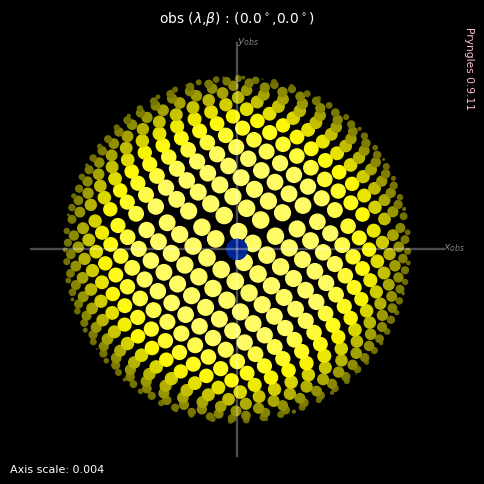

In [5]:
system.sg.plot2d()

## **Transit Lightcurve**

In [13]:
times = np.linspace(-0.5, 0.5, 100)

# Integrating and Computing Lightcurve
system.compute_lightcurve(times*pr.Consts.days/system.ut)

Computing Lightcurve : 100%|██████████| 100/100 [00:41<00:00,  2.44it/s]


### **Setting Up Detector**

In [14]:
DETECTOR_PROPERTIES = dict(
    # Waveband
    wavelength_min = 500e-9, # [m]
    wavelength_max = 700e-9, # [m] 
    # Apperture
    apperture = 0.5, # [m]
    # Quantum Efficiency
    quantum_eff = 1,
    # Time of Cadence    
    t_cadence = 10*60, # Minutes [s]
    # Observer Distance
    distance = 1*1e3*pr.Consts.pc # Kilo Parsec [m]
)

# ------------------------------------------------------

detector = pr.Detector(**DETECTOR_PROPERTIES)

detector.set_source(star)

print(f'Source Flux [photons/cadence]: {detector.normal_flux}')

print(detector.__dict__)

Source Flux [photons/cadence]: 4537.644962360599
{'wavelength_min': 5e-07, 'wavelength_max': 7e-07, 'apperture': 0.5, 'quantum_eff': 1, 't_cadence': 600, 'distance': 3.085677581e+19, 'units': ['au', 'msun', 'yr2pi'], 'normal_flux': 4537.644962360599}


### **Generating Signal**

In [15]:
detector.generate_signal(system.lightcurve['times']*system.ut, system.lightcurve['flux'])

## **Plotting Lightcurve**

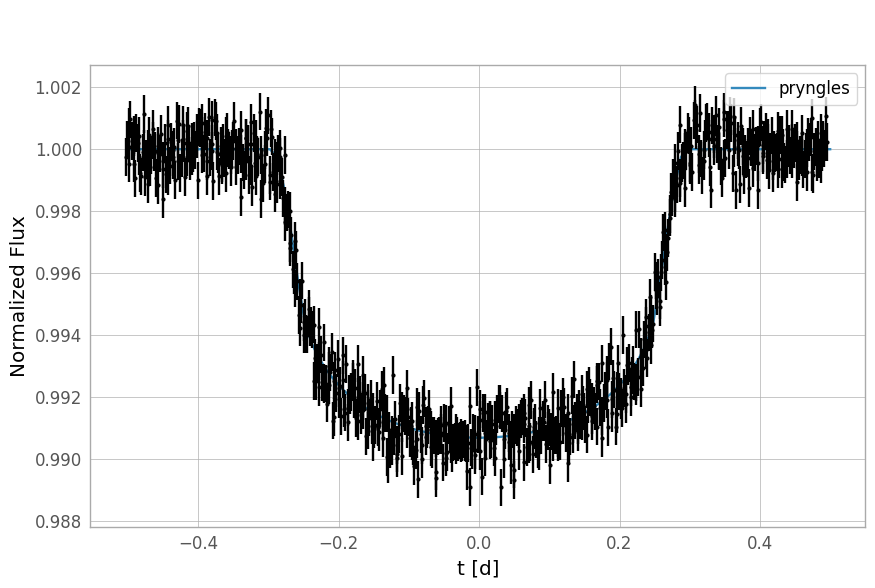

In [ ]:
plt.figure(figsize = (10,6))

plt.plot(times, system.lightcurve['flux'], label = 'pryngles')
plt.errorbar(detector.times/pr.Consts.days, detector.signal_flux, yerr = detector.signal_error, fmt = 'o', color = 'k', markersize = 2)

plt.title('\n')
plt.xlabel('t [d]')
plt.ylabel('Normalized Flux')

plt.legend()
plt.grid(linewidth = 0.5) 

plt.show()